Setup complete


/workspaces/myfolder/sas-curiosity-cup-2025/src/data/fetch.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False)


Downloaded 499 days of data

NVDA Real Data:
Current Price: $180.99
Historical Return: 78.99% per year
Historical Volatility: 51.22% per year

Running Monte Carlo with NVDA data...


/workspaces/myfolder/sas-curiosity-cup-2025/src/data/fetch.py:83: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(data['Close'].iloc[-1])
/workspaces/myfolder/sas-curiosity-cup-2025/src/data/fetch.py:58: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  mu = float(daily_mean * 252)
/workspaces/myfolder/sas-curiosity-cup-2025/src/data/fetch.py:59: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  sigma = float(daily_std * np.sqrt(252))



6-Month Forecast for NVDA:
Expected Price: $319.45
Median Price: $290.84
95% VaR: $143.99 (95% chance stays above this)
99% VaR: $110.06 (99% chance stays above this)
Probability of Loss: 13.7%


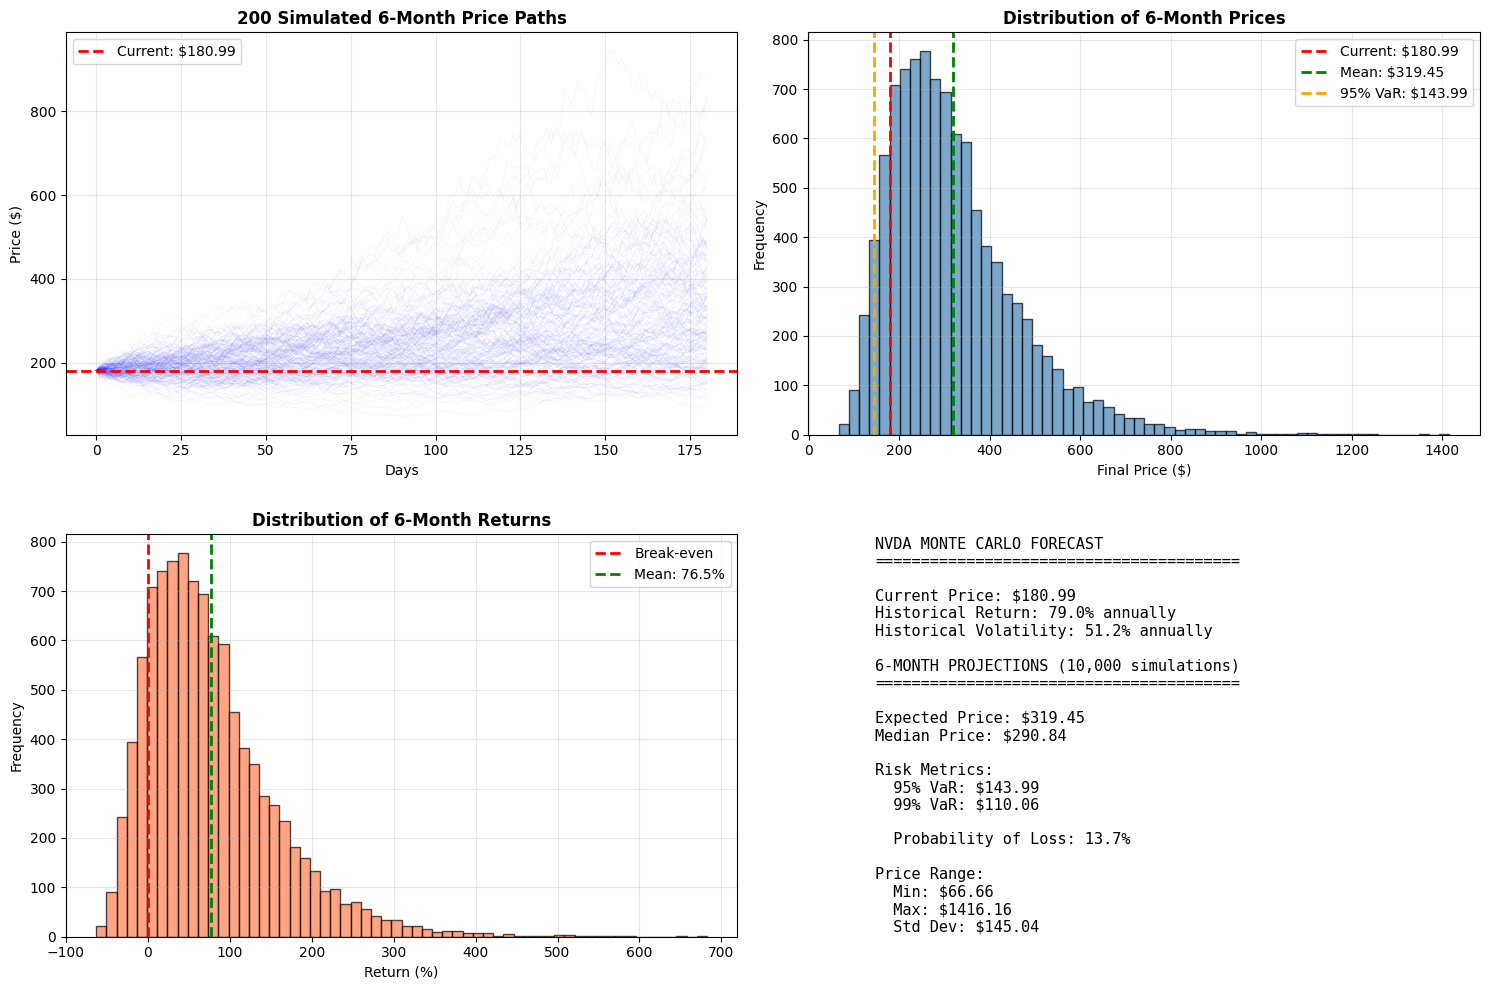

In [1]:
# Cell 1: Setup
import sys
import os

#importing monte carlo
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(repo_root)

from src.models.monte_carlo import MonteCarloSimulator
from src.data.fetch import get_stock_parameters
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta

print("Setup complete")

# Cell 2: Get NVDA parameters
end_date = datetime.now().strftime('%Y-%m-%d')
start_date = (datetime.now() - timedelta(days=730)).strftime('%Y-%m-%d')

params = get_stock_parameters('NVDA', start_date, end_date)

print(f"\nNVDA Real Data:")
print(f"Current Price: ${params['S0']:.2f}")
print(f"Historical Return: {params['mu']*100:.2f}% per year")
print(f"Historical Volatility: {params['sigma']*100:.2f}% per year")

# Cell 3: Run Monte Carlo with parameters
print("\nRunning Monte Carlo with NVDA data...")

sim = MonteCarloSimulator(
    S0=params['S0'],      # Real current price
    mu=params['mu'],      # Real historical return
    sigma=params['sigma'], # Real historical volatility
    days=180              # Predict 6 months ahead
)

# Run 10,000 simulations
paths = sim.run_simulation(n_simulations=10000)
final_prices = paths[:, -1]

stats = sim.get_statistics(final_prices)

print("\n6-Month Forecast for NVDA:")
print(f"Expected Price: ${stats['mean']:.2f}")
print(f"Median Price: ${stats['median']:.2f}")
print(f"95% VaR: ${stats['var_95']:.2f} (95% chance stays above this)")
print(f"99% VaR: ${stats['var_99']:.2f} (99% chance stays above this)")
print(f"Probability of Loss: {stats['prob_loss']*100:.1f}%")

# Cell 4: Visualize
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Sample paths
ax1 = axes[0, 0]
for i in range(200):
    ax1.plot(paths[i], alpha=0.05, color='blue', linewidth=0.5)
ax1.axhline(y=params['S0'], color='red', linestyle='--', linewidth=2, label=f"Current: ${params['S0']:.2f}")
ax1.set_title('200 Simulated 6-Month Price Paths', fontweight='bold')
ax1.set_xlabel('Days')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Distribution of final prices
ax2 = axes[0, 1]
ax2.hist(final_prices, bins=60, edgecolor='black', alpha=0.7, color='steelblue')
ax2.axvline(params['S0'], color='red', linestyle='--', linewidth=2, label=f"Current: ${params['S0']:.2f}")
ax2.axvline(stats['mean'], color='green', linestyle='--', linewidth=2, label=f"Mean: ${stats['mean']:.2f}")
ax2.axvline(stats['var_95'], color='orange', linestyle='--', linewidth=2, label=f"95% VaR: ${stats['var_95']:.2f}")
ax2.set_title('Distribution of 6-Month Prices', fontweight='bold')
ax2.set_xlabel('Final Price ($)')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Probability of different returns
ax3 = axes[1, 0]
returns = (final_prices / params['S0'] - 1) * 100
ax3.hist(returns, bins=60, edgecolor='black', alpha=0.7, color='coral')
ax3.axvline(0, color='red', linestyle='--', linewidth=2, label='Break-even')
ax3.axvline(returns.mean(), color='green', linestyle='--', linewidth=2, label=f"Mean: {returns.mean():.1f}%")
ax3.set_title('Distribution of 6-Month Returns', fontweight='bold')
ax3.set_xlabel('Return (%)')
ax3.set_ylabel('Frequency')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Risk metrics summary
ax4 = axes[1, 1]
ax4.axis('off')
summary_text = f"""
NVDA MONTE CARLO FORECAST
{'='*40}

Current Price: ${params['S0']:.2f}
Historical Return: {params['mu']*100:.1f}% annually
Historical Volatility: {params['sigma']*100:.1f}% annually

6-MONTH PROJECTIONS (10,000 simulations)
{'='*40}

Expected Price: ${stats['mean']:.2f}
Median Price: ${stats['median']:.2f}

Risk Metrics:
  95% VaR: ${stats['var_95']:.2f}
  99% VaR: ${stats['var_99']:.2f}
  
  Probability of Loss: {stats['prob_loss']*100:.1f}%
  
Price Range:
  Min: ${stats['min']:.2f}
  Max: ${stats['max']:.2f}
  Std Dev: ${stats['std']:.2f}
"""
ax4.text(0.1, 0.5, summary_text, fontsize=11, family='monospace', verticalalignment='center')

plt.tight_layout()
plt.show()